<div style="display:flex; justify-content:center; align-items:center; position:relative;">

  <h2 style="margin:auto; text-align:center;">
    UNIVERSIDAD TÉCNICA DEL NORTE <br>
    Facultad de Ingeniería en Ciencias Aplicadas - FICA
  </h2>

  <img src="https://wstemproject.eu/files/2019/06/logo-UTN-2017-768x768.png"
       width="100px">
</div>

<h4 style="text-align:center;"> CARRERA DE CIENCIA DE DATOS E INTELIGENCIA ARTIFICIAL </h4>

<h4 style="text-align:center;"> PROGRAMACIÓN II </h4>

<h4 style="text-align:center;"> Exploratory Data Analysis  </h4>

<h5 style="text-align:right;"> Docente: Ing. Wilson Pérez </h5>
<h5 style="text-align:right;"> Marzo - Septiembre 2026</h5>

***
### 4. Exploratory Data Analysis
***

#### 4.1. ¿Qué es EDA?

Eda del siglo en inglés Exploratory Data Analysis y consiste en una de las primeras tareas que tiene que desempeñar el Científico de Datos.

Es cuando revisamos por primera vez los datos que nos llegan, por ejemplo un archivo CSV que nos entregan y deberemos intentar comprender "¿de qué se trata?".

Identificar posibles patrones y reconociendo distribuciones estadísticas que puedan ser útiles en el futuro.

##### 4.1.1. ¿Qué se busca?

Al llegar un archivo, lo primero que deberíamos hacer es intentar responder:

- ¿Cuántos registros hay?
    - ¿Son demasiado pocos?
    - ¿Son muchos y no tenemos Capacidad (CPU+RAM) suficiente para procesarlo?
- ¿Están todas las filas completas ó tenemos campos con valores nulos?
    - En caso que haya demasiados nulos: ¿Queda el resto de información inútil?
- ¿Que datos son discretos y cuales continuos?
    - Muchas veces sirve obtener el tipo de datos: texto, int, double, float
- ¿Cuales parecen ser features (características) importantes? ¿Cuales podemos descartar?
- ¿Siguen alguna distribución?
- ¿Hay correlación entre features?
- ¿Cuales son los Outliers? (unos pocos datos aislados que difieren drásticamente del resto y “contaminan” ó desvían las distribuciones)
    - Podemos eliminarlos? es importante conservarlos?
    - son errores de carga o son reales?

Puede ocurrir que tengamos set de datos incompletos y debamos pedir a nuestro cliente/proveedor ó interesado que nos brinde mayor información de los campos, que aporte más conocimiento ó que corrija campos.

##### 4.1.2. ¿Qué se obtiene con el EDA?

El EDA es *una primer aproximación a los datos*.

***Si estamos mas o menos bien preparados y suponiendo una muestra de datos “suficiente”, puede que en “unas horas” tengamos ya varias conclusiones*** como por ejemplo:

- Esto que quiere hacer el cliente CON ESTOS DATOS es una locura imposible!.
- No tenemos datos suficientes ó son de muy mala calidad (pedir más al cliente).
- No hace falta usar Machine Learning para resolver lo que pide el cliente.
- Es todo tan aleatorio que no habrá manera de detectar patrones.
- Hay datos suficientes y de buena calidad como para seguir a la próxima etapa.

- A estas alturas podemos saber si nos están pidiendo algo viable ó si necesitamos más datos para comenzar.

***
#### 4.2. Práctica: Exploratory Data Analysis

#### Tema: Análisis de clientes y predicción simple de abandono

##### Contexto

Una empresa de telecomunicaciones desea analizar el comportamiento de sus clientes para identificar patrones relacionados con el abandono del servicio.

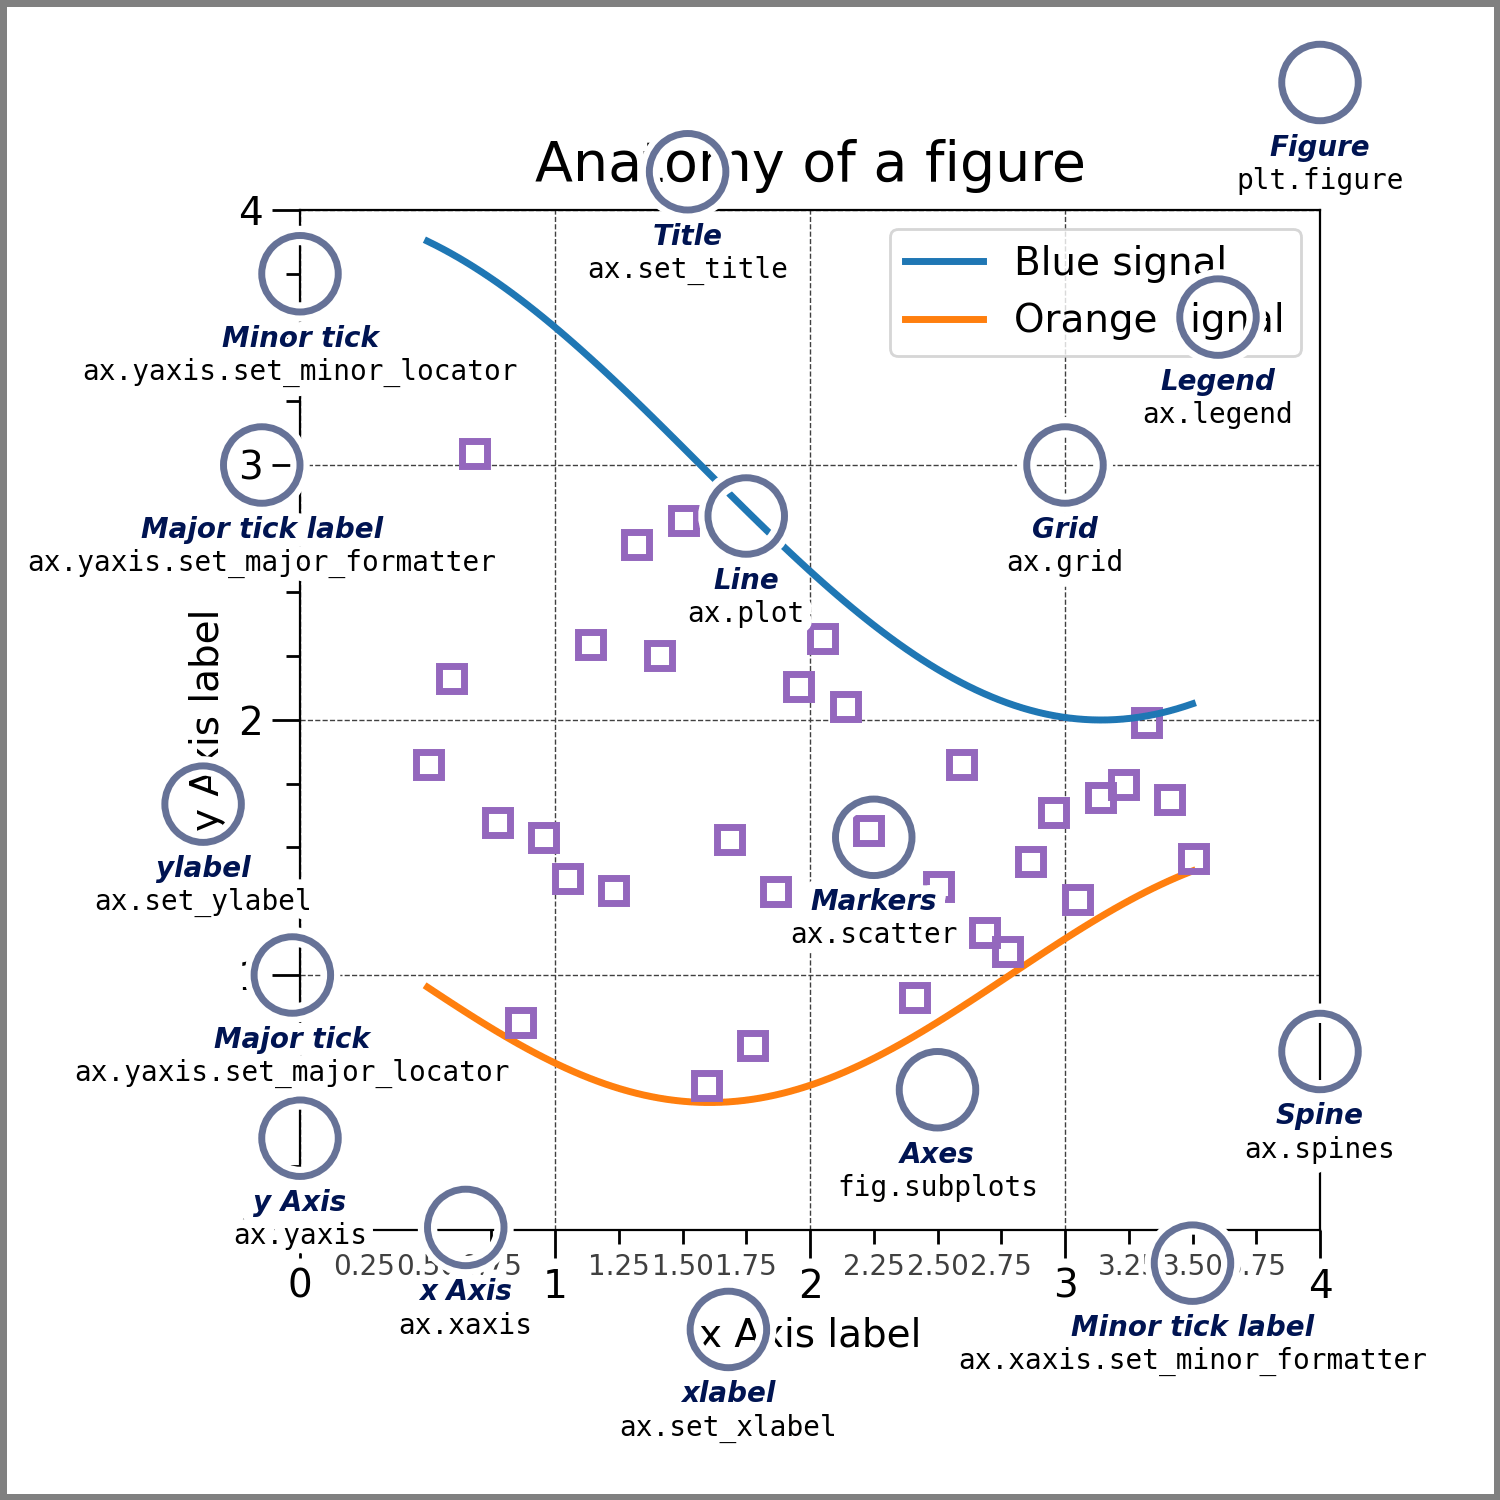

In [2]:
#clientes_telecom.csv

https://github.com/wilsonperezrc/varios/blob/main/img/clientes_telecom.csv

| Columna | Descripción |
|---|---|
| Cliente_ID | Identificador del cliente |
| Edad | Edad del cliente |
| Genero | Masculino/Femenino |
| Ciudad | Ciudad del cliente |
| Plan | Básico, Estándar, Premium |
| Meses_Cliente | Antigüedad del cliente |
| Consumo_GB | Consumo mensual de internet |
| Llamadas_Min | Minutos de llamadas mensuales |
| Pago_Mensual | Valor pagado al mes |
| Reclamos | Número de reclamos |
| Soporte_Contactos | Contactos con soporte |
| Metodo_Pago | Tarjeta, Transferencia, Efectivo |
| Abandono | Sí/No |


#### Objetivo general

Realizar un análisis exploratorio completo para identificar qué factores se relacionan con el abandono de clientes.

#### 1. Importar librerías

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#### 2. Leer el dataset

In [4]:
path = '/Users/wilsonperez/Downloads/clientes_telecom.csv'

df = pd.read_csv(path, sep=',', header=0)

#### Mostrar

In [5]:
df.head(2)

,Cliente_ID,Edad,Genero,Ciudad,Plan,Meses_Cliente,Consumo_GB,Llamadas_Min,Pago_Mensual,Reclamos,Soporte_Contactos,Metodo_Pago,Abandono
0,1,56.0,Femenino,Cuenca,Estándar,21,42.61,819,60.44,0,1,Transferencia,No
1,2,55.0,Femenino,Ambato,Básico,42,16.58,881,30.11,0,2,Tarjeta,No


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Cliente_ID         255 non-null    int64  
 1   Edad               250 non-null    float64
 2   Genero             255 non-null    object 
 3   Ciudad             255 non-null    object 
 4   Plan               255 non-null    object 
 5   Meses_Cliente      255 non-null    int64  
 6   Consumo_GB         250 non-null    float64
 7   Llamadas_Min       255 non-null    int64  
 8   Pago_Mensual       255 non-null    float64
 9   Reclamos           255 non-null    int64  
 10  Soporte_Contactos  255 non-null    int64  
 11  Metodo_Pago        250 non-null    object 
 12  Abandono           255 non-null    object 
dtypes: float64(3), int64(5), object(5)
memory usage: 26.0+ KB


In [7]:
print(df.shape)

(255, 13)


#### 3. Limpieza de datos
##### a) Identificar valores nulos

In [8]:
print(df.isnull().sum())

Cliente_ID           0
Edad                 5
Genero               0
Ciudad               0
Plan                 0
Meses_Cliente        0
Consumo_GB           5
Llamadas_Min         0
Pago_Mensual         0
Reclamos             0
Soporte_Contactos    0
Metodo_Pago          5
Abandono             0
dtype: int64


##### b) Rellenar valores faltantes

In [9]:
print(df["Edad"].median())

45.0


In [10]:
print(df["Edad"][58:61])

58    49.0
59     NaN
60    54.0
Name: Edad, dtype: float64


In [11]:
df["Edad"].fillna(df["Edad"].median())

0      56.0
1      55.0
2      20.0
3      53.0
4      33.0
       ... 
250    21.0
251    31.0
252    50.0
253    62.0
254    59.0
Name: Edad, Length: 255, dtype: float64

In [12]:
print(df["Edad"][58:61])

58    49.0
59     NaN
60    54.0
Name: Edad, dtype: float64


In [13]:
df["Edad"] = df["Edad"].fillna(df["Edad"].median())

In [14]:
print(df["Edad"][58:61])

58    49.0
59    45.0
60    54.0
Name: Edad, dtype: float64


In [15]:
df["Consumo_GB"] = df["Consumo_GB"].fillna(df["Consumo_GB"].mean())
df["Metodo_Pago"] = df["Metodo_Pago"].fillna("No registrado")

#### c) Eliminar duplicados

In [16]:
print(df.shape)

(255, 13)


In [17]:
df = df.drop_duplicates()

In [18]:
print(df.shape)

(250, 13)


d) Corregir valores inconsistentes

In [19]:
df["Genero"].unique()

array(['Femenino ', 'Femenino', 'MAsculino', 'Masculino', 'FEmenino',
       'MASCULINO'], dtype=object)

In [20]:
df["Plan"].unique()

array(['Estándar', 'Básico', 'Premium', 'BÁSICO'], dtype=object)

In [21]:
df["Plan"].unique()

array(['Estándar', 'Básico', 'Premium', 'BÁSICO'], dtype=object)

In [22]:
df["Genero"] = df["Genero"].str.strip().str.capitalize()
df["Ciudad"] = df["Ciudad"].str.strip().str.title()
df["Plan"] = df["Plan"].str.strip().str.capitalize()

In [23]:
print(df["Genero"].unique())
print(df["Plan"].unique())
print(df["Plan"].unique())

['Femenino' 'Masculino']
['Estándar' 'Básico' 'Premium']
['Estándar' 'Básico' 'Premium']


#### 4. Crear nuevas variables
##### a) Gasto total estimado

In [24]:
df["Gasto_Total"] = df["Meses_Cliente"] * df["Pago_Mensual"]

In [25]:
df.head(2)

,Cliente_ID,Edad,Genero,Ciudad,Plan,Meses_Cliente,Consumo_GB,Llamadas_Min,Pago_Mensual,Reclamos,Soporte_Contactos,Metodo_Pago,Abandono,Gasto_Total
0,1,56.0,Femenino,Cuenca,Estándar,21,42.61,819,60.44,0,1,Transferencia,No,1269.24
1,2,55.0,Femenino,Ambato,Básico,42,16.58,881,30.11,0,2,Tarjeta,No,1264.62


##### b) Nivel de consumo

In [26]:
df["Nivel_Consumo"] = pd.cut(
    df["Consumo_GB"],
    bins=[0, 20, 50, 100, np.inf],
    labels=["Bajo", "Medio", "Alto", "Muy alto"]
)
df.head(2)

,Cliente_ID,Edad,Genero,Ciudad,Plan,Meses_Cliente,Consumo_GB,Llamadas_Min,Pago_Mensual,Reclamos,Soporte_Contactos,Metodo_Pago,Abandono,Gasto_Total,Nivel_Consumo
0,1,56.0,Femenino,Cuenca,Estándar,21,42.61,819,60.44,0,1,Transferencia,No,1269.24,Medio
1,2,55.0,Femenino,Ambato,Básico,42,16.58,881,30.11,0,2,Tarjeta,No,1264.62,Bajo


##### c) Cliente problemático

In [27]:
df["Cliente_Problematico"] = np.where(
    df["Reclamos"] >= 3,
    "Sí",
    "No"
)
df.head(2)

,Cliente_ID,Edad,Genero,Ciudad,Plan,Meses_Cliente,Consumo_GB,Llamadas_Min,Pago_Mensual,Reclamos,Soporte_Contactos,Metodo_Pago,Abandono,Gasto_Total,Nivel_Consumo,Cliente_Problematico
0,1,56.0,Femenino,Cuenca,Estándar,21,42.61,819,60.44,0,1,Transferencia,No,1269.24,Medio,No
1,2,55.0,Femenino,Ambato,Básico,42,16.58,881,30.11,0,2,Tarjeta,No,1264.62,Bajo,No


##### d) Convertir abandono a valor numérico

In [28]:
df["Abandono_Num"] = np.where(df["Abandono"] == "Sí", 1, 0)
df.head(2)

,Cliente_ID,Edad,Genero,Ciudad,Plan,Meses_Cliente,Consumo_GB,Llamadas_Min,Pago_Mensual,Reclamos,Soporte_Contactos,Metodo_Pago,Abandono,Gasto_Total,Nivel_Consumo,Cliente_Problematico,Abandono_Num
0,1,56.0,Femenino,Cuenca,Estándar,21,42.61,819,60.44,0,1,Transferencia,No,1269.24,Medio,No,0
1,2,55.0,Femenino,Ambato,Básico,42,16.58,881,30.11,0,2,Tarjeta,No,1264.62,Bajo,No,0


#### 5. Estadística descriptiva

In [29]:
print(df.describe())

       Cliente_ID        Edad  Meses_Cliente  Consumo_GB  Llamadas_Min  \
count  250.000000  250.000000     250.000000  250.000000    250.000000   
mean   125.500000   43.332000      30.908000   47.241286    657.716000   
std     72.312977   14.628388      17.235306   29.247907    316.669876   
min      1.000000   18.000000       1.000000    1.420000     50.000000   
25%     63.250000   31.000000      15.250000   23.225000    412.750000   
50%    125.500000   45.000000      31.000000   43.370000    684.000000   
75%    187.750000   56.000000      45.750000   61.077500    934.250000   
max    250.000000   69.000000      59.000000  144.620000   1186.000000   

       Pago_Mensual    Reclamos  Soporte_Contactos  Gasto_Total  Abandono_Num  
count    250.000000  250.000000         250.000000   250.000000    250.000000  
mean      51.201720    1.528000           2.168000  1587.107960      0.292000  
std       23.932563    1.283669           1.432475  1214.552553      0.455594  
min       17.

In [30]:
print("Edad promedio:", df["Edad"].mean())
print("Pago mensual promedio:", df["Pago_Mensual"].mean())
print("Consumo promedio:", df["Consumo_GB"].mean())
print("Porcentaje de abandono:", df["Abandono_Num"].mean() * 100)

Edad promedio: 43.332
Pago mensual promedio: 51.20172
Consumo promedio: 47.24128640000001
Porcentaje de abandono: 29.2


#### 6. Análisis agrupado
##### a) Abandono por plan

In [31]:
df.groupby("Plan")["Abandono_Num"].mean()

Plan
Básico      0.372549
Estándar    0.234694
Premium     0.240000
Name: Abandono_Num, dtype: float64

In [32]:
abandono_plan = df.groupby("Plan")["Abandono_Num"].mean() * 100
print(abandono_plan)

Plan
Básico      37.254902
Estándar    23.469388
Premium     24.000000
Name: Abandono_Num, dtype: float64


##### b) Reclamos promedio por abandono

In [33]:
reclamos_abandono = df.groupby("Abandono")["Reclamos"].mean()
print(reclamos_abandono)

Abandono
No    1.361582
Sí    1.931507
Name: Reclamos, dtype: float64


##### c) Pago mensual promedio por tipo de plan

##### d) Abandono por ciudad



#### 7. Visualizaciones
##### a) Gráfico de barras: abandono por plan

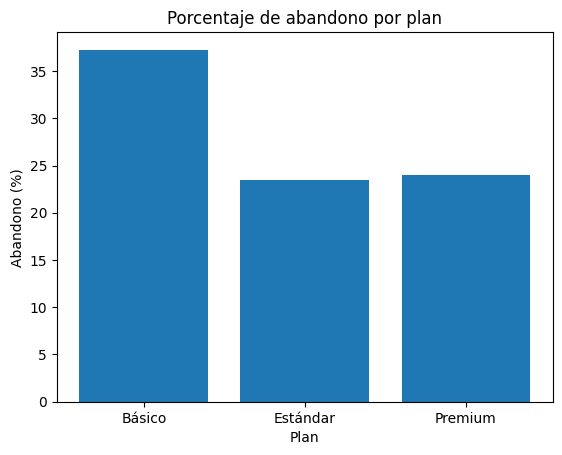

In [34]:
plt.bar(abandono_plan.index , abandono_plan.values)

plt.title("Porcentaje de abandono por plan")
plt.xlabel("Plan")
plt.ylabel("Abandono (%)")
plt.show()

##### b) Histograma de edad

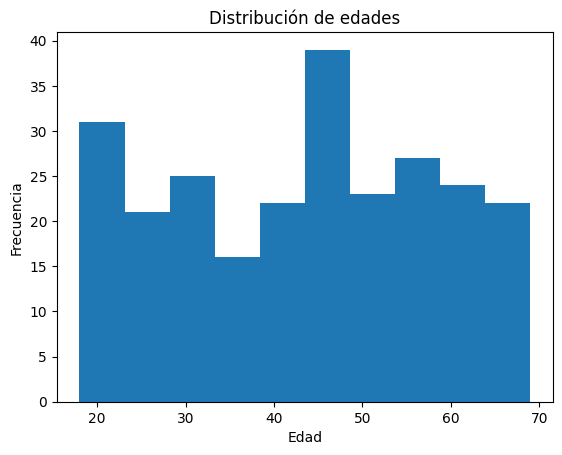

In [35]:
plt.hist(df["Edad"])

plt.title("Distribución de edades")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

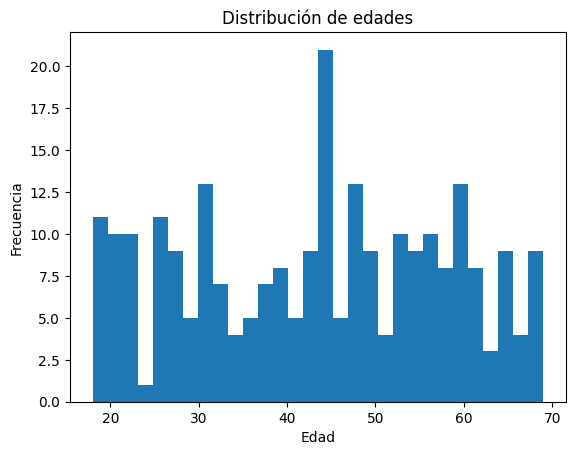

In [36]:
plt.hist(df["Edad"], bins=30)

plt.title("Distribución de edades")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

##### c) Diagrama de dispersión

Relación entre consumo y pago mensual.

##### d) Boxplot de pago mensual por abandono

In [37]:
#  by=""


##### e) Gráfico de líneas: gasto total promedio por meses como cliente

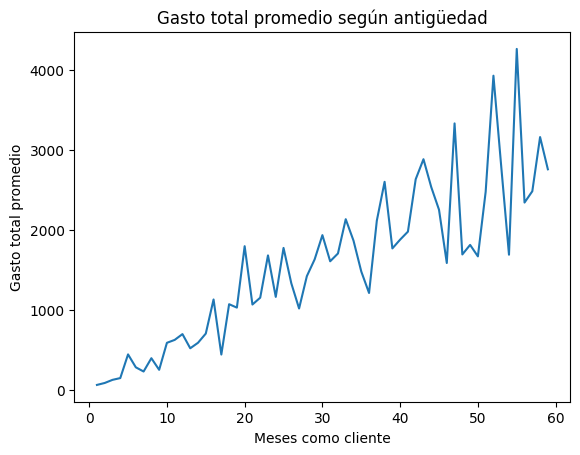

In [38]:
# groupby()[]

gasto_meses = df.groupby("Meses_Cliente")["Gasto_Total"].mean()

plt.plot(gasto_meses.index, gasto_meses.values)

plt.title("Gasto total promedio según antigüedad")
plt.xlabel("Meses como cliente")
plt.ylabel("Gasto total promedio")
plt.show()


#### 8. Correlación
Seleccionar variables numéricas:

In [39]:
nums = df[
    [
        "Edad",
        "Meses_Cliente",
        "Consumo_GB",
        "Llamadas_Min",
        "Pago_Mensual",
        "Reclamos",
        "Soporte_Contactos",
        "Gasto_Total",
        "Abandono_Num"
    ]
]

Calcular matriz de correlación:

In [40]:
correlacion = nums.corr()
print(correlacion)

                       Edad  Meses_Cliente  Consumo_GB  Llamadas_Min  \
Edad               1.000000      -0.003845    0.004641      0.003829   
Meses_Cliente     -0.003845       1.000000   -0.040709     -0.071485   
Consumo_GB         0.004641      -0.040709    1.000000     -0.104855   
Llamadas_Min       0.003829      -0.071485   -0.104855      1.000000   
Pago_Mensual      -0.013621       0.011112    0.825420     -0.095835   
Reclamos          -0.003812       0.000934    0.040249     -0.034021   
Soporte_Contactos  0.024159       0.071876   -0.007364      0.056369   
Gasto_Total        0.027443       0.708825    0.465789     -0.128981   
Abandono_Num       0.028782      -0.123405   -0.089585      0.075430   

                   Pago_Mensual  Reclamos  Soporte_Contactos  Gasto_Total  \
Edad                  -0.013621 -0.003812           0.024159     0.027443   
Meses_Cliente          0.011112  0.000934           0.071876     0.708825   
Consumo_GB             0.825420  0.040249       

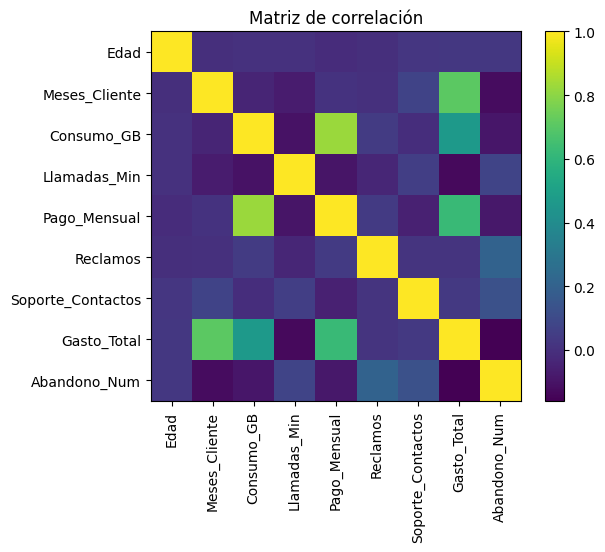

In [41]:
plt.imshow(correlacion)
plt.colorbar()

plt.xticks(range(len(correlacion.columns)), correlacion.columns, rotation=90)
plt.yticks(range(len(correlacion.columns)), correlacion.columns)

plt.title("Matriz de correlación")
plt.show()

#### 9. Segmentación de clientes
Crear una columna llamada Segmento.

In [42]:
condiciones = [
    (df["Pago_Mensual"] >= 80) & (df["Meses_Cliente"] >= 24),
    (df["Reclamos"] >= 3),
    (df["Consumo_GB"] >= 80),
    (df["Pago_Mensual"] < 40)
]

segmentos = [
    "Cliente valioso",
    "Cliente en riesgo",
    "Alto consumo",
    "Bajo ingreso"
]

df["Segmento"] = np.select(condiciones, segmentos, default="Cliente regular")

In [43]:
df.head(5)

,Cliente_ID,Edad,Genero,Ciudad,Plan,Meses_Cliente,Consumo_GB,Llamadas_Min,Pago_Mensual,Reclamos,Soporte_Contactos,Metodo_Pago,Abandono,Gasto_Total,Nivel_Consumo,Cliente_Problematico,Abandono_Num,Segmento
0,1,56.0,Femenino,Cuenca,Estándar,21,42.61,819,60.44,0,1,Transferencia,No,1269.24,Medio,No,0,Cliente regular
1,2,55.0,Femenino,Ambato,Básico,42,16.58,881,30.11,0,2,Tarjeta,No,1264.62,Bajo,No,0,Bajo ingreso
2,3,20.0,Masculino,Cuenca,Premium,18,128.26,255,82.12,4,2,Tarjeta,No,1478.16,Muy alto,Sí,0,Cliente en riesgo
3,4,53.0,Masculino,Loja,Básico,54,32.19,345,27.77,1,6,Tarjeta,Sí,1499.58,Medio,No,1,Bajo ingreso
4,5,33.0,Masculino,Quito,Estándar,25,62.85,697,78.41,1,1,Efectivo,Sí,1960.25,Alto,No,1,Cliente regular


#### 10. Mini modelo de clasificación manual

Crear una regla simple para predecir abandono:

In [44]:
df["Prediccion_Abandono"] = np.where(
    (df["Reclamos"] >= 3) | (df["Soporte_Contactos"] >= 4) | (df["Meses_Cliente"] < 6),
    1,
    0
)

In [45]:
df[["Reclamos", "Soporte_Contactos", "Meses_Cliente", "Abandono_Num", "Prediccion_Abandono"]].head(20)

,Reclamos,Soporte_Contactos,Meses_Cliente,Abandono_Num,Prediccion_Abandono
0,0,1,21,0,0
1,0,2,42,0,0
2,4,2,18,0,1
3,1,6,54,1,1
4,1,1,25,1,0
5,0,1,59,0,0
6,3,4,44,1,1
7,1,2,32,0,0
8,0,2,28,1,0
9,1,1,37,1,0


Evaluar aciertos:

In [46]:
df["Acierto"] = np.where(
    df["Prediccion_Abandono"] == df["Abandono_Num"],
    1,
    0
)

In [47]:
df[["Reclamos", "Soporte_Contactos", "Meses_Cliente", "Abandono_Num", "Prediccion_Abandono", "Acierto"]].head(20)

,Reclamos,Soporte_Contactos,Meses_Cliente,Abandono_Num,Prediccion_Abandono,Acierto
0,0,1,21,0,0,1
1,0,2,42,0,0,1
2,4,2,18,0,1,0
3,1,6,54,1,1,1
4,1,1,25,1,0,0
5,0,1,59,0,0,1
6,3,4,44,1,1,1
7,1,2,32,0,0,1
8,0,2,28,1,0,0
9,1,1,37,1,0,0


In [48]:
precision_manual = df["Acierto"].mean() * 100

print("Precisión del modelo manual:", precision_manual)

Precisión del modelo manual: 67.2


***
#### 4.3. Preguntas para responder

##### ¿Qué plan presenta mayor porcentaje de abandono?

In [60]:
# Calcular porcentaje de abandono por plan


Plan
Básico      37.254902
Estándar    23.469388
Premium     24.000000
Name: Abandono_Num, dtype: float64


##### ¿Los clientes con más reclamos abandonan más?

In [59]:
# Promedio de reclamos según abandono


Abandono
No    1.361582
Sí    1.931507
Name: Reclamos, dtype: float64


In [58]:
# Porcentaje de abandono según número de reclamos


Reclamos
0    22.033898
1    24.675325
2    23.809524
3    50.000000
4    54.545455
5    33.333333
6    66.666667
Name: Abandono_Num, dtype: float64


##### ¿Existe relación entre pago mensual y abandono?


In [57]:
# Promedio de pago mensual según abandono


Abandono
No    52.524237
Sí    47.995068
Name: Pago_Mensual, dtype: float64


##### ¿Qué ciudad tiene mayor abandono?


Ciudad
Ambato       22.857143
Cuenca       22.222222
Guayaquil    21.621622
Loja         32.608696
Manta        33.333333
Quito        38.888889
Name: Abandono_Num, dtype: float64


##### ¿Qué segmento de clientes es más riesgoso?


In [55]:
# Calcular porcentaje de abandono por segmento


Segmento
Alto consumo         21.428571
Bajo ingreso         29.069767
Cliente en riesgo    53.333333
Cliente regular      18.518519
Cliente valioso      25.000000
Name: Abandono_Num, dtype: float64


##### ¿La regla manual de predicción funciona bien?

##### ¿Qué acciones podría tomar la empresa para reducir el abandono?

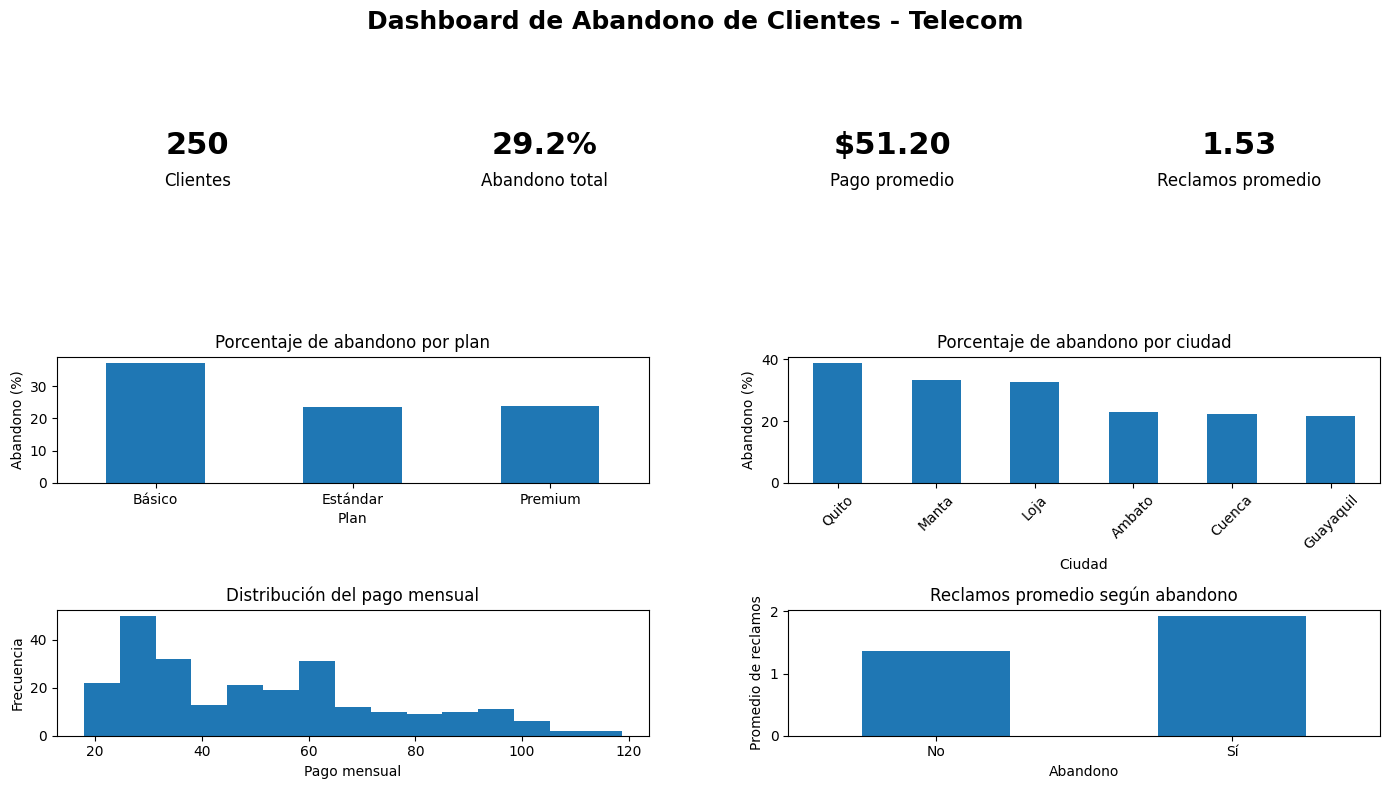

In [54]:
# Indicadores principales
total_clientes = len(df)
abandono_total = df["Abandono_Num"].mean() * 100
pago_promedio = df["Pago_Mensual"].mean()
reclamos_promedio = df["Reclamos"].mean()

# Datos para gráficos
abandono_plan = df.groupby("Plan")["Abandono_Num"].mean() * 100
abandono_ciudad = df.groupby("Ciudad")["Abandono_Num"].mean() * 100
abandono_ciudad = abandono_ciudad.sort_values(ascending=False)
reclamos_abandono = df.groupby("Abandono")["Reclamos"].mean()

# Crear dashboard
fig = plt.figure(figsize=(14, 8))
fig.suptitle("Dashboard de Abandono de Clientes - Telecom", fontsize=18, fontweight="bold")

# Tarjeta: total clientes
ax0 = fig.add_subplot(3, 4, 1)
ax0.text(0.5, 0.6, f"{total_clientes}", ha="center", fontsize=22, fontweight="bold")
ax0.text(0.5, 0.35, "Clientes", ha="center", fontsize=12)
ax0.axis("off")

# Tarjeta: abandono total
ax1 = fig.add_subplot(3, 4, 2)
ax1.text(0.5, 0.6, f"{abandono_total:.1f}%", ha="center", fontsize=22, fontweight="bold")
ax1.text(0.5, 0.35, "Abandono total", ha="center", fontsize=12)
ax1.axis("off")

# Tarjeta: pago promedio
ax2 = fig.add_subplot(3, 4, 3)
ax2.text(0.5, 0.6, f"${pago_promedio:.2f}", ha="center", fontsize=22, fontweight="bold")
ax2.text(0.5, 0.35, "Pago promedio", ha="center", fontsize=12)
ax2.axis("off")

# Tarjeta: reclamos promedio
ax3 = fig.add_subplot(3, 4, 4)
ax3.text(0.5, 0.6, f"{reclamos_promedio:.2f}", ha="center", fontsize=22, fontweight="bold")
ax3.text(0.5, 0.35, "Reclamos promedio", ha="center", fontsize=12)
ax3.axis("off")

# Gráfico 1: abandono por plan
ax4 = fig.add_subplot(3, 2, 3)
abandono_plan.plot(kind="bar", ax=ax4)
ax4.set_title("Porcentaje de abandono por plan")
ax4.set_xlabel("Plan")
ax4.set_ylabel("Abandono (%)")
ax4.tick_params(axis="x", rotation=0)

# Gráfico 2: abandono por ciudad
ax5 = fig.add_subplot(3, 2, 4)
abandono_ciudad.plot(kind="bar", ax=ax5)
ax5.set_title("Porcentaje de abandono por ciudad")
ax5.set_xlabel("Ciudad")
ax5.set_ylabel("Abandono (%)")
ax5.tick_params(axis="x", rotation=45)

# Gráfico 3: distribución de pago mensual
ax6 = fig.add_subplot(3, 2, 5)
ax6.hist(df["Pago_Mensual"], bins=15)
ax6.set_title("Distribución del pago mensual")
ax6.set_xlabel("Pago mensual")
ax6.set_ylabel("Frecuencia")

# Gráfico 4: reclamos promedio según abandono
ax7 = fig.add_subplot(3, 2, 6)
reclamos_abandono.plot(kind="bar", ax=ax7)
ax7.set_title("Reclamos promedio según abandono")
ax7.set_xlabel("Abandono")
ax7.set_ylabel("Promedio de reclamos")
ax7.tick_params(axis="x", rotation=0)

# Ajustar diseño
plt.tight_layout(rect=[0, 0, 1, 0.93])

# Mostrar dashboard
plt.show()